In [1]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt

import echopype as ep

In [2]:
path_Sv = "/Volumes/sh2506_ext1/leg1_test/Sv"
path_MVBS = "/Volumes/sh2506_ext1/leg1_test/MVBS"

In [3]:
Sv_files = sorted(list(Path(path_Sv).glob("*.zarr")))
len(Sv_files)

317

In [4]:
MVBS_files = sorted(list(Path(path_MVBS).glob("*.zarr")))
len(MVBS_files)

164

In [5]:
ds_MVBS_combine = xr.open_mfdataset(
    MVBS_files[-15:],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
)

In [6]:
ds_MVBS_combine = ep.consolidate.swap_dims_channel_frequency(ds_MVBS_combine)

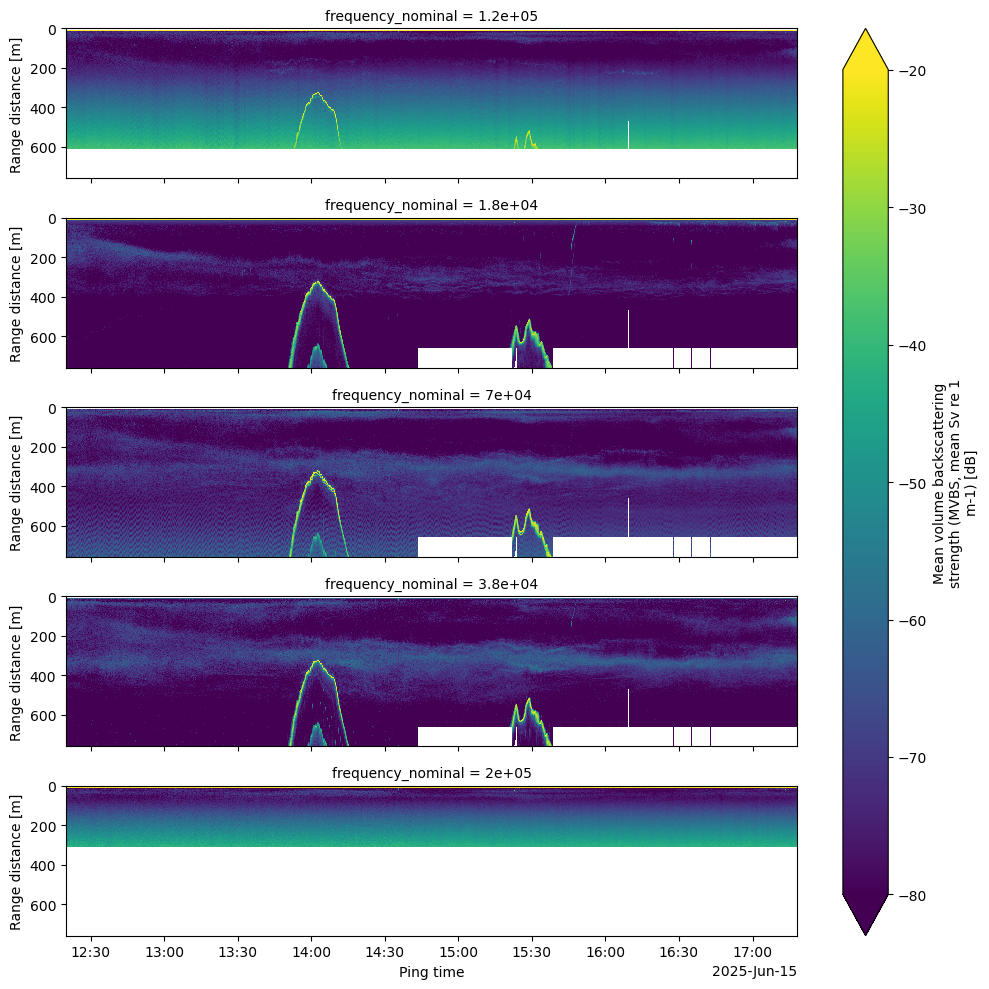

In [7]:
ds_MVBS_combine["Sv"].plot(
    x="ping_time", y="depth",
    row="frequency_nominal", col_wrap=1,
    figsize=(10, 10),
    cmap="viridis", vmin=-80, vmax=-20, yincrease=False,
)

(700.0, 600.0)

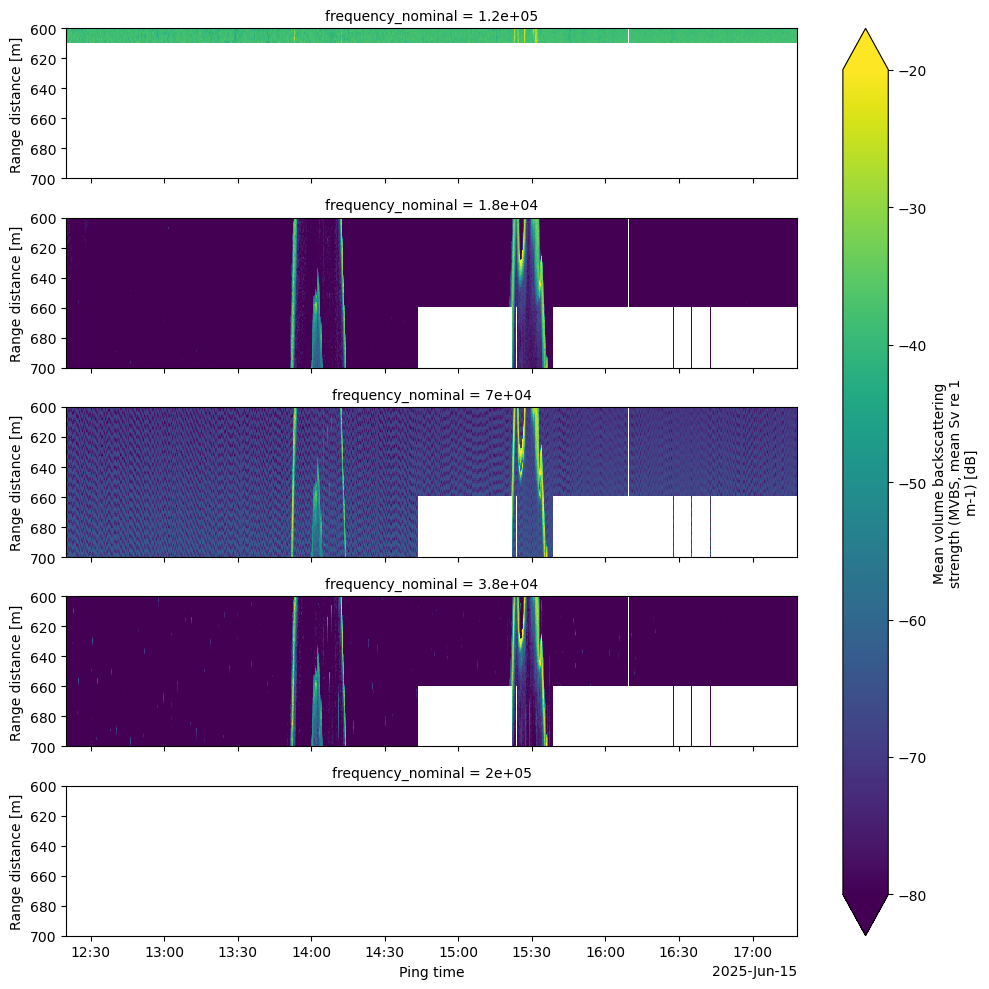

In [8]:
ds_MVBS_combine["Sv"].plot(
    x="ping_time", y="depth",
    row="frequency_nominal", col_wrap=1,
    figsize=(10, 10),
    cmap="viridis", vmin=-80, vmax=-20, yincrease=False,
)
plt.ylim(700, 600)